In [1]:
import sys
sys.version, sys.executable

('3.10.20 | packaged by Anaconda, Inc. | (main, Mar 11 2026, 17:42:35) [MSC v.1942 64 bit (AMD64)]',
 'C:\\Users\\brend\\.conda\\envs\\tcga_env\\python.exe')

In [2]:
import os
import pandas as pd #data manupulation
import numpy as np #numeric calculation
import matplotlib.pyplot as plt #data visualization
import seaborn as sns #for data visualization
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, classification_report, roc_auc_score, roc_curve
# Models
from sklearn.preprocessing import StandardScaler, Normalizer, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier

print("All packages have been installed successfully!")

All packages have been installed successfully!


In [3]:
path = r"C:\Users\brend\Downloads\patient-class-prediction"
train_data = pd.read_csv(os.path.join(path, r"train.csv"))
test_data = pd.read_csv(os.path.join(path, r"test.csv"))

In [4]:
print(f"Train data matrix: {train_data.shape}\n")
print(f"Test data matrix: {test_data.shape}\n")

# 80% of data- already split for training.

Train data matrix: (20000, 25)

Test data matrix: (5000, 25)



In [5]:
print(f"Train data columns: {train_data.columns.to_list}\n")


Train data columns: <bound method IndexOpsMixin.tolist of Index(['PatientID', 'Street', 'Location', 'Latitude', 'Longitude',
       'Admission_Type', 'Discharge_Disposition', 'Admission_Date',
       'Discharge_Date', 'Length_of_Stay', 'Age', 'Gender', 'Ethnicity',
       'Primary_Diagnosis', 'Secondary_Diagnosis', 'Procedure_Code',
       'Procedure_Description', 'Comorbidities', 'Medication', 'Follow_Up',
       'Insurance', 'Notes', 'Doctor_Comments', 'Medication_Details',
       'Admission_Category'],
      dtype='object')>



In [6]:
# find missing values
train_data.isnull().sum()


# I will be dropping theses variable as they dont provide any insight:
#PatientID , Street, Location, Latitude, Longitude,Discharge_Disposition,
#Admission_Date,Discharge_Date, Primary_Diagnosis, Secondary_Diagnosis,Procedure_Description,
#Medication, Follow_Up, Insurance,Notes,Doctor_Comments,Medication_Details 
# Therefore there is no need to continue with dropping the missing values

PatientID                    0
Street                   12000
Location                  2000
Latitude                     0
Longitude                    0
Admission_Type               0
Discharge_Disposition        0
Admission_Date               0
Discharge_Date               0
Length_of_Stay               0
Age                          0
Gender                       0
Ethnicity                    0
Primary_Diagnosis            0
Secondary_Diagnosis          0
Procedure_Code               0
Procedure_Description        0
Comorbidities                0
Medication                   0
Follow_Up                14000
Insurance                    0
Notes                     2000
Doctor_Comments              0
Medication_Details           0
Admission_Category           0
dtype: int64

In [7]:
# total missing values in training dataset
train_data.isna().sum().sum()

30000

In [8]:
# total missing values in test dataset
test_data.isna().sum().sum()

0

In [9]:
# Admission type= Newborn is inconsistent with age
# check for any inconsistent labeling: check admission_type and admission_category for both train and test

train_data.loc[(train_data['Age'])&(train_data['Admission_Type']=='Newborn'),
    ['Age', 'Admission_Type']]

,Age,Admission_Type
1,69,Newborn
14,95,Newborn
18,17,Newborn
20,93,Newborn
22,25,Newborn
...,...,...
19967,35,Newborn
19975,57,Newborn
19977,57,Newborn
19993,19,Newborn


In [10]:
# Admission type= Newborn is inconsistent with age
test_data.loc[(test_data['Age'])&(test_data['Admission_Type']=='Newborn'),
    ['Age', 'Admission_Type']]

,Age,Admission_Type
1,11,Newborn
3,39,Newborn
5,11,Newborn
10,75,Newborn
13,83,Newborn
...,...,...
4950,99,Newborn
4951,75,Newborn
4954,87,Newborn
4979,51,Newborn


In [11]:
test_data.loc[(test_data['Age']==0)&(test_data['Admission_Type']=='Newborn'),
    ['Age', 'Admission_Type']]

#newborn is Age==0

,Age,Admission_Type
657,0,Newborn
1119,0,Newborn
2578,0,Newborn
3547,0,Newborn
4661,0,Newborn
4749,0,Newborn
4779,0,Newborn


In [12]:
train_data[['Admission_Type']].value_counts()

Admission_Type
Newborn           5068
Elective          5045
Emergency         4957
Urgent            4930
Name: count, dtype: int64

In [13]:
# train and test df keeping Age==0 for Newborn categories + keep all other categories
train_data= train_data[
    (train_data['Admission_Type']!= 'Newborn')|
    (train_data['Age']==0)
]
train_data= train_data[
    (train_data['Admission_Category']!= 'Newborn')|
    (train_data['Age']==0)
]
test_data= test_data[
    (test_data['Admission_Type']!= 'Newborn')|
    (test_data['Age']==0)
]
test_data= test_data[
    (test_data['Admission_Category']!= 'Newborn')|
    (test_data['Age']==0)
]

In [14]:
print(f"Train dataset matrix after Newborn&Age filtering: {train_data.shape}")
print(f"Test dataset matrix after Newborn&Age filtering: {test_data.shape}")

Train dataset matrix after Newborn&Age filtering: (11917, 25)
Test dataset matrix after Newborn&Age filtering: (2973, 25)


In [34]:
# columns that I chose that will help the models
columns_keep=[
    'Length_of_Stay',
    'Age',
    'Primary_Diagnosis',
    'Secondary_Diagnosis',
    'Procedure_Code',
    'Comorbidities',
    'Admission_Category'
]

train_df_polished = train_data[columns_keep].copy()
test_df_polished = test_data[columns_keep].copy()

In [35]:
print(f"Train dataset matrix - with hand selected variables that will help the models: {train_df_polished.shape, train_df_polished.columns.to_list()}\n")

print(f"Test dataset matrix - with hand selected variables that will help the models: {test_df_polished.shape, test_df_polished.columns.to_list()}")

Train dataset matrix - with hand selected variables that will help the models: ((11917, 7), ['Length_of_Stay', 'Age', 'Primary_Diagnosis', 'Secondary_Diagnosis', 'Procedure_Code', 'Comorbidities', 'Admission_Category'])

Test dataset matrix - with hand selected variables that will help the models: ((2973, 7), ['Length_of_Stay', 'Age', 'Primary_Diagnosis', 'Secondary_Diagnosis', 'Procedure_Code', 'Comorbidities', 'Admission_Category'])


In [36]:
# keep this to check for proper alignment of 1=yes and 0=no
train_df_polished.head()
# comorbidities and Admission_Category are strings need numeric conversion

,Length_of_Stay,Age,Primary_Diagnosis,Secondary_Diagnosis,Procedure_Code,Comorbidities,Admission_Category
0,24,80,D04,B07,1171,No,Urgent
2,11,73,C03,B07,2847,Yes,Urgent
3,19,2,C03,E10,9219,No,Urgent
4,6,16,B02,A06,4751,No,Urgent
5,7,35,C03,D09,5815,Yes,Urgent


In [37]:
# keep this to check for proper alignment of 1=yes and 0=no
test_df_polished.head()

,Length_of_Stay,Age,Primary_Diagnosis,Secondary_Diagnosis,Procedure_Code,Comorbidities,Admission_Category
0,6,97,C03,C08,9093,Yes,Urgent
2,10,77,B02,A06,2816,No,Urgent
4,19,26,B02,D09,1512,Yes,Emergency
7,8,30,D04,C08,5737,Yes,Urgent
8,22,42,C03,A06,2170,No,Urgent


In [38]:
# Make comorbidities into binary encoding
# 1= yes and 0=no

train_df_polished['Comorbidities']= (
    train_data['Comorbidities'].astype(str).str.strip().str.lower().apply(lambda x: 1 if x=='yes' else 0)
    
)

test_df_polished['Comorbidities']= (
    test_data['Comorbidities'].astype(str).str.strip().str.lower().apply(lambda x: 1 if x=='yes' else 0)
    
)

df1_head= pd.DataFrame(train_df_polished['Comorbidities'].head())
df2_head= pd.DataFrame(test_df_polished['Comorbidities'].head())

print(f"Check the train_df_polished and train_data alighment match to Comorbities binary alignment:\n{df1_head}\n")
print(f"Check the test_df_polished and test_data alighment match to Comorbities binary alignment:\n{df2_head}")


#---------------------------------
# Correct alignment, continue...
#---------------------------------

Check the train_df_polished and train_data alighment match to Comorbities binary alignment:
   Comorbidities
0              0
2              1
3              0
4              0
5              1

Check the test_df_polished and test_data alighment match to Comorbities binary alignment:
   Comorbidities
0              1
2              0
4              1
7              1
8              0


In [39]:
train_df_polished['Admission_Category'].unique()

array(['Urgent', 'Emergency', 'Newborn', 'Elective'], dtype=object)

In [40]:
train_df_polished.shape, test_df_polished.shape

((11917, 7), (2973, 7))

In [41]:
# Final check for null values
print(f"Null values in train dataset {train_df_polished.isnull().sum().sum()}")
print(f"Null values in test dataset {test_df_polished.isnull().sum().sum()}")


# zero missing values, continue.

Null values in train dataset 0
Null values in test dataset 0


In [42]:
grids= {
    "Logistic Regression": {
        "C": [0.01, 0.1, 1, 10],
        "solver": ["lbfgs"],
        "class_weight": ["balanced"],
    },

    "Random Forest": {
        "n_estimators": [50,100],
        "max_depth": [5,10,None], 
        "class_weight": ["balanced"],

    },

    "XGBOOST": {
        "objective": ["multi:softmax"],
        "eval_metric": ["mlogloss"],
        "learning_rate": [.001, .01],
        "n_estimators": [50,100],
        "max_depth": [3,5],
        "subsample":[.5,.8],
        "colsample_bytree": [.5,.8],
    }

}

models = {
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    "XGBOOST": XGBClassifier()
}

In [43]:
X_train = train_df_polished.drop('Admission_Category', axis=1)
X_test= test_df_polished.drop('Admission_Category', axis=1)

# Pandas one hot encoded
X_train_oh= pd.get_dummies(X_train, columns=['Primary_Diagnosis','Secondary_Diagnosis','Procedure_Code'])
X_test_oh= pd.get_dummies(X_test, columns=['Primary_Diagnosis','Secondary_Diagnosis','Procedure_Code'])

In [44]:
# y train and y test
y_train= train_df_polished['Admission_Category']
y_test= test_df_polished['Admission_Category']

# apply labelencoder to string admission categories
le= LabelEncoder()
y_train_le= le.fit_transform(y_train)
y_test_le= le.transform(y_test)

In [45]:
X_train_oh, X_test_oh= X_train_oh.align(
    X_test_oh,
    join='left',
    axis=1,
    fill_value=0
)

In [46]:
#scalers
scaler= StandardScaler()

# fit on training data
X_s_scaled= scaler.fit_transform(X_train_oh)

# fit on testing data using the SAME fitted scalers
X_test_scaled= scaler.transform(X_test_oh)

In [47]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results=[]


#stores best models for future plotting
best_models={}

for name, model in models.items():
    print(f"Tuning {name}...")
    grid= GridSearchCV(
        estimator=model,
        param_grid= grids[name],
        cv=cv,
        scoring="roc_auc_ovr",
        n_jobs=1
    )
    grid.fit(X_s_scaled,y_train_le)
    best_model= grid.best_estimator_
    best_models[name]= best_model
    print(f"Best params: {grid.best_params_}")
    # evaluate on test dataset
    y_pred= best_model.predict(X_test_scaled)
    acc = accuracy_score(y_test_le, y_pred)

    print(f"Accuracy Score:{acc}\n")

    results.append([name, acc])

Final_results= pd.DataFrame(results,
                           columns=["Model", "Accuracy score"])
Final_results.sort_values(by="Accuracy score", ascending=False)

Tuning Logistic Regression...
Best params: {'C': 10, 'class_weight': 'balanced', 'solver': 'lbfgs'}
Accuracy Score:0.8631012445341406

Tuning Random Forest...
Best params: {'class_weight': 'balanced', 'max_depth': None, 'n_estimators': 100}
Accuracy Score:1.0

Tuning XGBOOST...
Best params: {'colsample_bytree': 0.5, 'eval_metric': 'mlogloss', 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'objective': 'multi:softmax', 'subsample': 0.8}
Accuracy Score:0.7571476622939791



,Model,Accuracy score
1,Random Forest,1.000000
0,Logistic Regression,0.863101
2,XGBOOST,0.757148


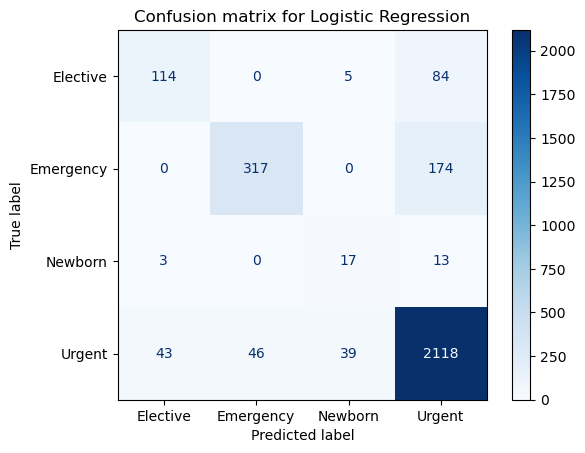

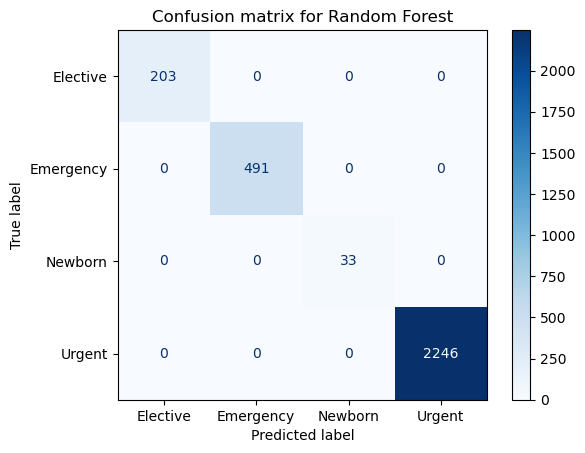

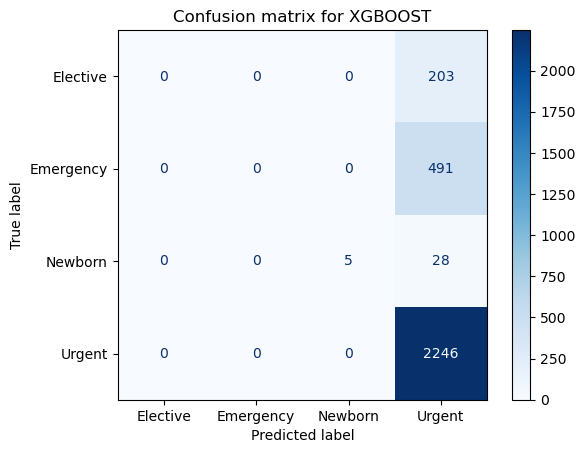

In [48]:
for name, model in best_models.items():
    ypred= model.predict(X_test_scaled)
    cm= confusion_matrix(y_test_le, ypred)
    
    disp= ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=le.classes_
    )
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion matrix for {name}")
    plt.show()




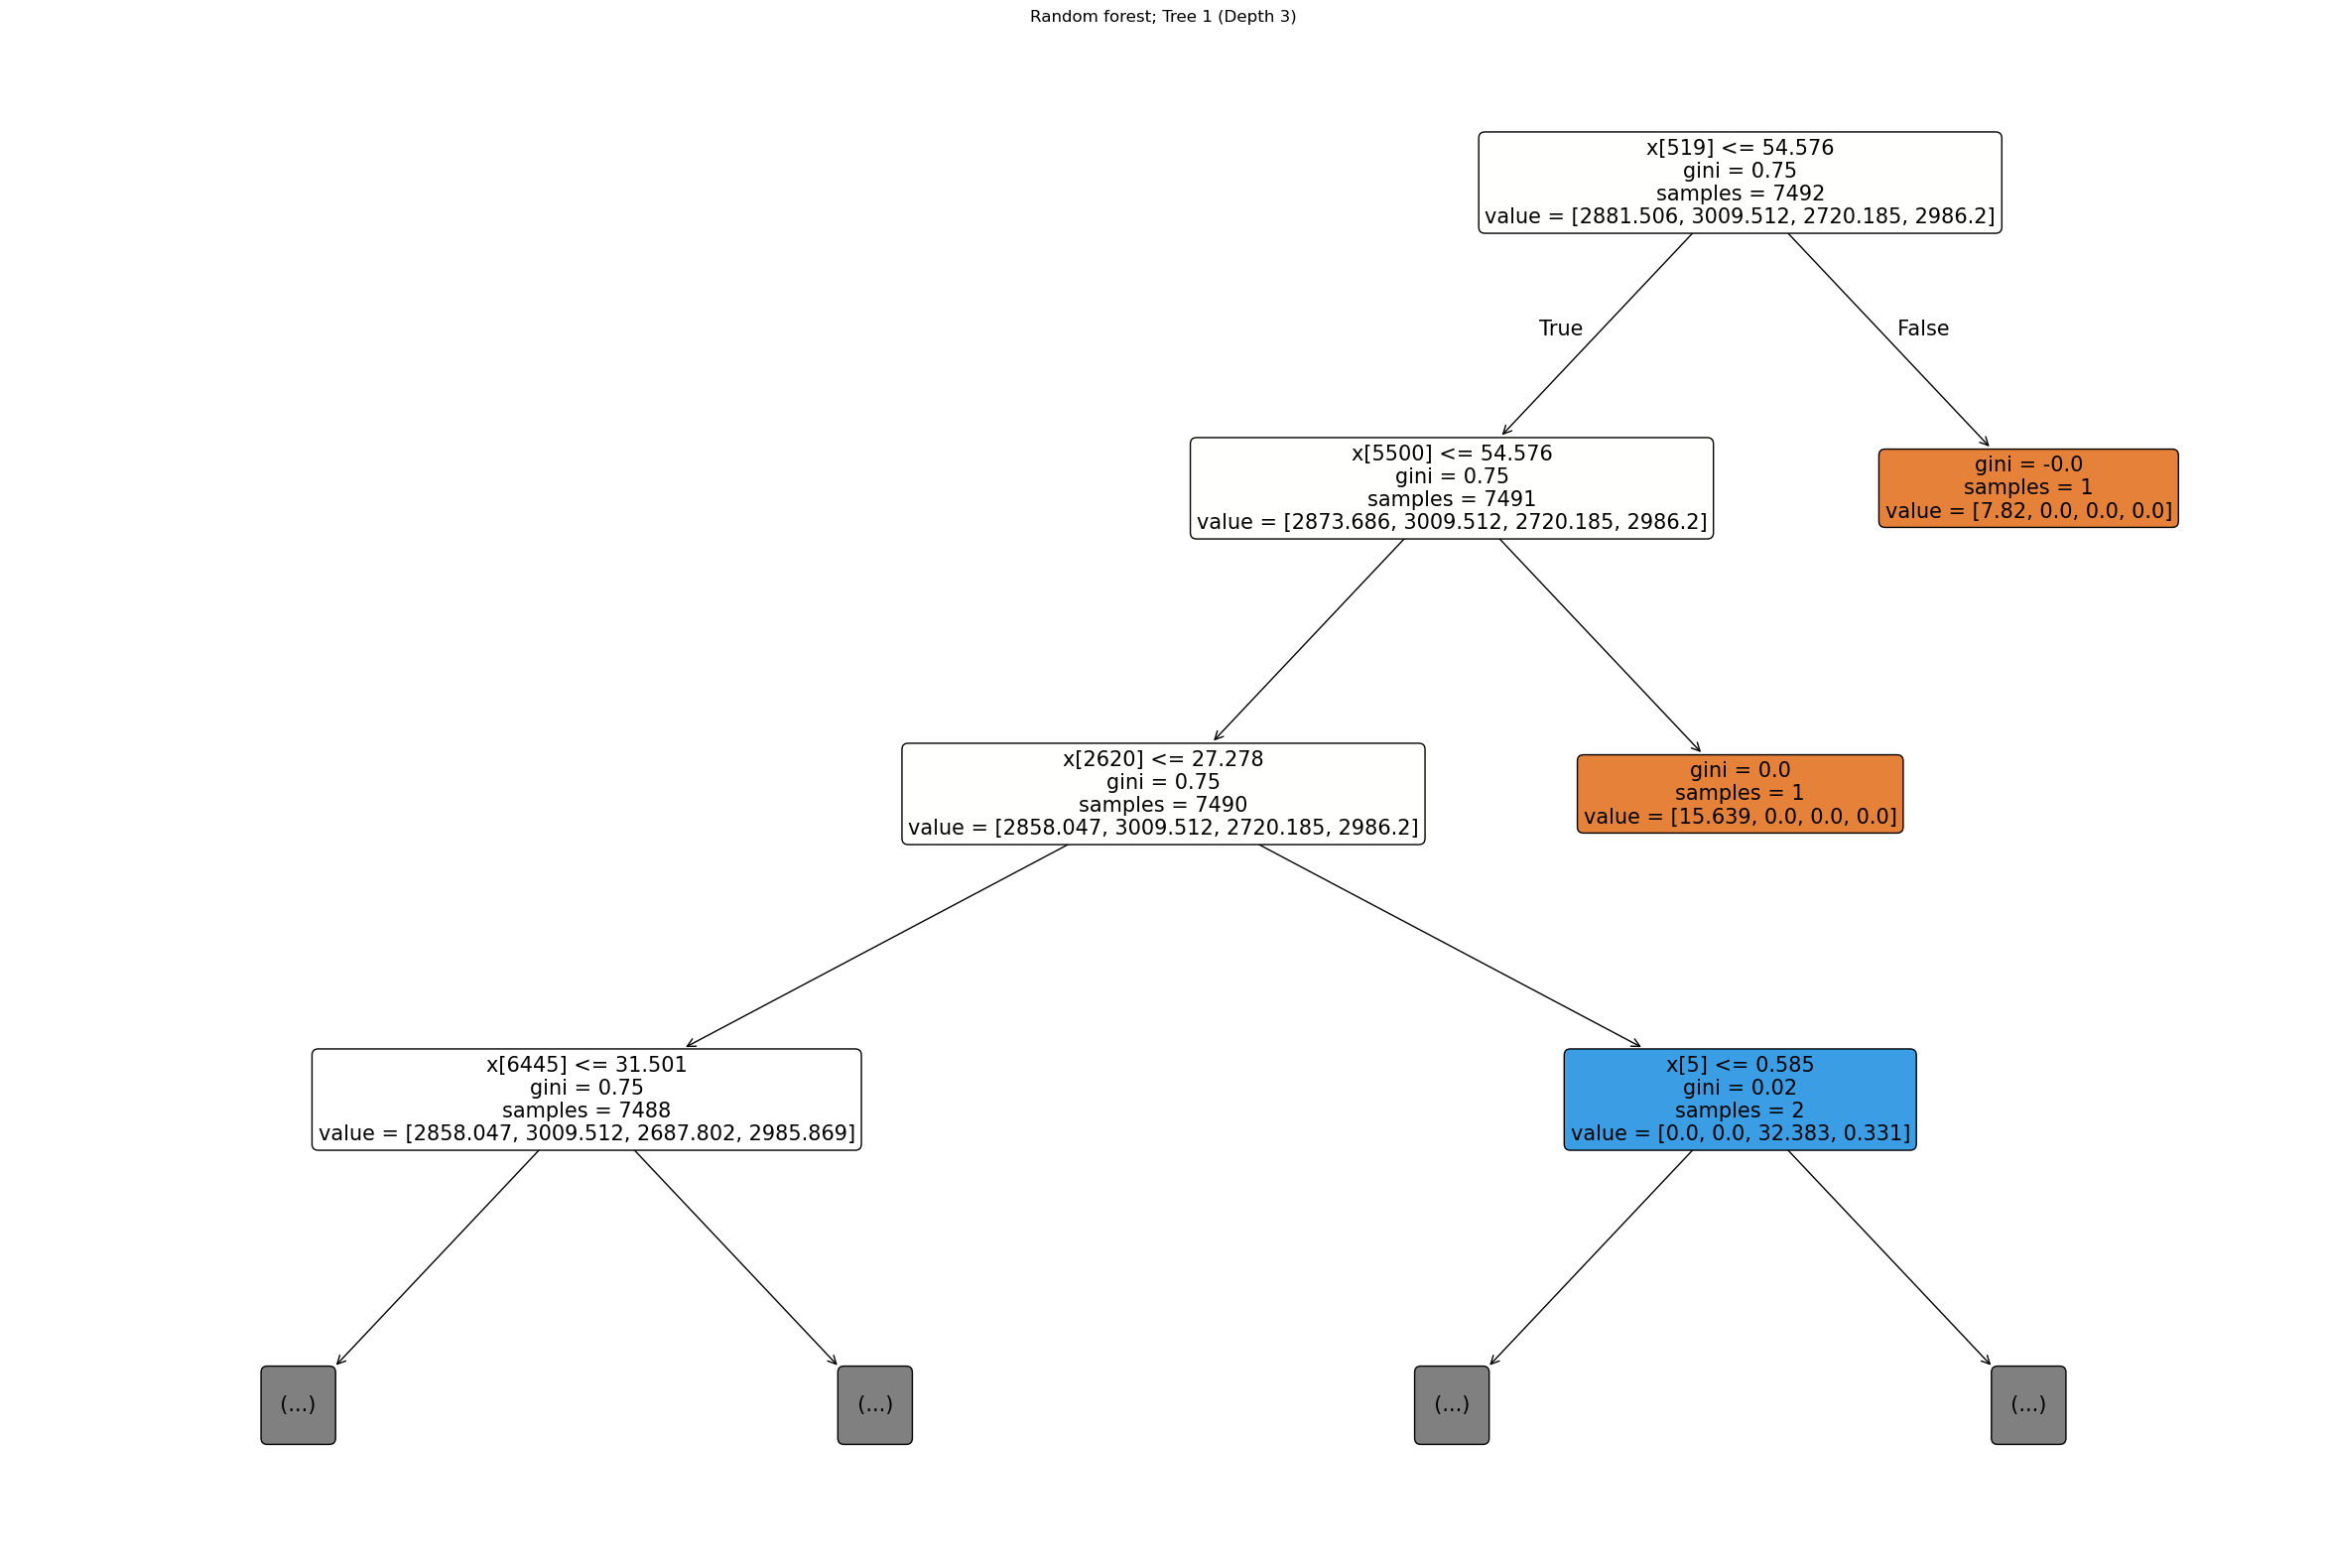

In [55]:
rf_model= best_models["Random Forest"]

plt.figure(figsize=(30,20))
plot_tree(
    rf_model.estimators_[0], #tree 1
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=15

)
plt.title("Random forest; Tree 1 (Depth 3)")
plt.show()